In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_280126/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
a01 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a01_results.csv')
a01_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a01_p005_results.csv')

a02 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a02_results.csv')
a02_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a02_p005_results.csv')

a025 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a025_results.csv')
a025_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a025_p005_results.csv')

a03 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a03_results.csv')
a03_p005 = pd.read_csv('/Users/kjesta/Desktop/LABDATA/Calculated_amps/20cm_f17_a03_p005_results.csv')

In [21]:
# For plotting
freq = 1.7
depth = 0.2

In [22]:
# Wavenumber
k = estimate_wavenumber(freq=1.3, depth=0.2)

# Theoretical damping coefficient
alpha_theo = spatial_damping_coefficient(k=k, D=0.2, H=0.15)

In [23]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker
plate_pos = np.array([6.34, 9.38])  # Positions of the plates, meters from wave maker

In [24]:
print(f'Theoretical damping coefficient at f={freq} Hz:', f'{alpha_theo:.4f} (1/m)')
print("--------------------------------")
print(f'Observed damping coefficients at f={freq} Hz, A=0.1 V (no plates):')
print(f'{a01["Alpha_obs"][0]:.4f}', f'{a01["Alpha_obs"][1]:.4f}', f'{a01["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Observed damping coefficients at f={freq} Hz, A=0.1 V (with 5 cm plates):')
print(f'{a01_p005["Alpha_obs"][0]:.4f}', f'{a01_p005["Alpha_obs"][1]:.4f}', f'{a01_p005["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a01_p005["Alpha_obs"][0] , a01_p005["Alpha_obs"][1], a01_p005["Alpha_obs"][2]]) - np.mean([a01["Alpha_obs"][0], a01["Alpha_obs"][1], a01["Alpha_obs"][2]]):.4f} (1/m)')
print("--------------------------------")
print(f'Observed damping coefficients at f={freq} Hz, A=0.2 V (no plates):')
print(f'{a02["Alpha_obs"][0]:.4f}', f'{a02["Alpha_obs"][1]:.4f}', f'{a02["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Observed damping coefficients at f={freq} Hz, A=0.2 V (with 5 cm plates):')
print(f'{a02_p005["Alpha_obs"][0]:.4f}', f'{a02_p005["Alpha_obs"][1]:.4f}', f'{a02_p005["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a02_p005["Alpha_obs"][0], a02_p005["Alpha_obs"][1], a02_p005["Alpha_obs"][2]]) - np.mean([a02["Alpha_obs"][0], a02["Alpha_obs"][1], a02["Alpha_obs"][2]]):.4f} (1/m)')
print("--------------------------------")
print(f'Observed damping coefficients at f={freq} Hz, A=0.25 V (no plates):')
print(f'{a025["Alpha_obs"][0]:.4f}', f'{a025["Alpha_obs"][1]:.4f}', f'{a025["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Observed damping coefficients at f={freq} Hz, A=0.25 V (with 5 cm plates):')
print(f'{a025_p005["Alpha_obs"][0]:.4f}', f'{a025_p005["Alpha_obs"][1]:.4f}', f'{a025_p005["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a025_p005["Alpha_obs"][0], a025_p005["Alpha_obs"][1], a025_p005["Alpha_obs"][2]]) - np.mean([a025["Alpha_obs"][0], a025["Alpha_obs"][1], a025["Alpha_obs"][2]]):.4f} (1/m)')
print("--------------------------------")
print(f'Observed damping coefficients at f={freq} Hz, A=0.3 V (no plates):')
print(f'{a03["Alpha_obs"][0]:.4f}', f'{a03["Alpha_obs"][1]:.4f}', f'{a03["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Observed damping coefficients at f={freq} Hz, A=0.3 V (with 5 cm plates):')
print(f'{a03_p005["Alpha_obs"][0]:.4f}', f'{a03_p005["Alpha_obs"][1]:.4f}', f'{a03_p005["Alpha_obs"][2]:.4f} (1/m)')
print()
print(f'Mean damping coefficient due to plates:')
print(f'{np.mean([a03_p005["Alpha_obs"][0], a03_p005["Alpha_obs"][1], a03_p005["Alpha_obs"][2]]) - np.mean([a03["Alpha_obs"][0], a03["Alpha_obs"][1], a03["Alpha_obs"][2]]):.4f} (1/m)')

Theoretical damping coefficient at f=1.7 Hz: 0.0148 (1/m)
--------------------------------
Observed damping coefficients at f=1.7 Hz, A=0.1 V (no plates):
0.0031 0.0080 0.0074 (1/m)

Observed damping coefficients at f=1.7 Hz, A=0.1 V (with 5 cm plates):
0.0140 0.0154 0.0150 (1/m)

Mean damping coefficient due to plates:
0.0087 (1/m)
--------------------------------
Observed damping coefficients at f=1.7 Hz, A=0.2 V (no plates):
0.0048 0.0086 0.0080 (1/m)

Observed damping coefficients at f=1.7 Hz, A=0.2 V (with 5 cm plates):
0.0232 0.0251 0.0245 (1/m)

Mean damping coefficient due to plates:
0.0171 (1/m)
--------------------------------
Observed damping coefficients at f=1.7 Hz, A=0.25 V (no plates):
0.0098 0.0040 0.0002 (1/m)

Observed damping coefficients at f=1.7 Hz, A=0.25 V (with 5 cm plates):
0.0151 0.0180 0.0175 (1/m)

Mean damping coefficient due to plates:
0.0122 (1/m)
--------------------------------
Observed damping coefficients at f=1.7 Hz, A=0.3 V (no plates):
0.0175 0.015

In [25]:
delta_amp_a01_r1 = a01.iloc[0]['P3_minus_P0']
da_dx_a01_r1 = delta_amp_a01_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_r1 = delta_amp_a01_r1 / a01.iloc[0]['Amp_obs_P0'] * 100
ak_a01_r1 = a01.iloc[0]['Amp_obs_P0']*k

delta_amp_a01_p005_r1 = a01_p005.iloc[0]['P3_minus_P0']
da_dx_a01_p005_r1 = delta_amp_a01_p005_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_p005_r1 = delta_amp_a01_p005_r1 / a01_p005.iloc[0]['Amp_obs_P0'] * 100
ak_a01_p005_r1 = a01_p005.iloc[0]['Amp_obs_P0']*k

delta_amp_a01_r2 = a01.iloc[1]['P3_minus_P0']
da_dx_a01_r2 = delta_amp_a01_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_r2 = delta_amp_a01_r2 / a01.iloc[1]['Amp_obs_P0'] * 100
ak_a01_r2 = a01.iloc[1]['Amp_obs_P0']*k

delta_amp_a01_p005_r2 = a01_p005.iloc[1]['P3_minus_P0']
da_dx_a01_p005_r2 = delta_amp_a01_p005_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_p005_r2 = delta_amp_a01_p005_r2 / a01_p005.iloc[1]['Amp_obs_P0'] * 100
ak_a01_p005_r2 = a01_p005.iloc[1]['Amp_obs_P0']*k

delta_amp_a01_r3 = a01.iloc[2]['P3_minus_P0']
da_dx_a01_r3 = delta_amp_a01_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_r3 = delta_amp_a01_r3 / a01.iloc[2]['Amp_obs_P0'] * 100
ak_a01_r3 = a01.iloc[2]['Amp_obs_P0']*k

delta_amp_a01_p005_r3 = a01_p005.iloc[2]['P3_minus_P0']
da_dx_a01_p005_r3 = delta_amp_a01_p005_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a01_p005_r3 = delta_amp_a01_p005_r3 / a01_p005.iloc[2]['Amp_obs_P0'] * 100
ak_a01_p005_r3 = a01_p005.iloc[2]['Amp_obs_P0']*k

In [26]:
delta_amp_a02_r1 = a02.iloc[0]['P3_minus_P0']
da_dx_a02_r1 = delta_amp_a02_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_r1 = delta_amp_a02_r1 / a02.iloc[0]['Amp_obs_P0'] * 100
ak_a02_r1 = a02.iloc[0]['Amp_obs_P0']*k

delta_amp_a02_p005_r1 = a02_p005.iloc[0]['P3_minus_P0']
da_dx_a02_p005_r1 = delta_amp_a02_p005_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_p005_r1 = delta_amp_a02_p005_r1 / a02_p005.iloc[0]['Amp_obs_P0'] * 100
ak_a02_p005_r1 = a02_p005.iloc[0]['Amp_obs_P0']*k

delta_amp_a02_r2 = a02.iloc[1]['P3_minus_P0']
da_dx_a02_r2 = delta_amp_a02_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_r2 = delta_amp_a02_r2 / a02.iloc[1]['Amp_obs_P0'] * 100
ak_a02_r2 = a02.iloc[1]['Amp_obs_P0']*k

delta_amp_a02_p005_r2 = a02_p005.iloc[1]['P3_minus_P0']
da_dx_a02_p005_r2 = delta_amp_a02_p005_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_p005_r2 = delta_amp_a02_p005_r2 / a02_p005.iloc[1]['Amp_obs_P0'] * 100
ak_a02_p005_r2 = a02_p005.iloc[1]['Amp_obs_P0']*k

delta_amp_a02_r3 = a02.iloc[2]['P3_minus_P0']
da_dx_a02_r3 = delta_amp_a02_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_r3 = delta_amp_a02_r3 / a02.iloc[2]['Amp_obs_P0'] * 100
ak_a02_r3 = a02.iloc[2]['Amp_obs_P0']*k

delta_amp_a02_p005_r3 = a02_p005.iloc[2]['P3_minus_P0']
da_dx_a02_p005_r3 = delta_amp_a02_p005_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a02_p005_r3 = delta_amp_a02_p005_r3 / a02_p005.iloc[2]['Amp_obs_P0'] * 100
ak_a02_p005_r3 = a02_p005.iloc[2]['Amp_obs_P0']*k

In [27]:
delta_amp_a025_r1 = a025.iloc[0]['P3_minus_P0']
da_dx_a025_r1 = delta_amp_a025_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_r1 = delta_amp_a025_r1 / a025.iloc[0]['Amp_obs_P0'] * 100
ak_a025_r1 = a025.iloc[0]['Amp_obs_P0']*k

delta_amp_a025_p005_r1 = a025_p005.iloc[0]['P3_minus_P0']
da_dx_a025_p005_r1 = delta_amp_a025_p005_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_p005_r1 = delta_amp_a025_p005_r1 / a025_p005.iloc[0]['Amp_obs_P0'] * 100
ak_a025_p005_r1 = a025_p005.iloc[0]['Amp_obs_P0']*k

delta_amp_a025_r2 = a025.iloc[1]['P3_minus_P0']
da_dx_a025_r2 = delta_amp_a025_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_r2 = delta_amp_a025_r2 / a025.iloc[1]['Amp_obs_P0'] * 100
ak_a025_r2 = a025.iloc[1]['Amp_obs_P0']*k

delta_amp_a025_p005_r2 = a025_p005.iloc[1]['P3_minus_P0']
da_dx_a025_p005_r2 = delta_amp_a025_p005_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_p005_r2 = delta_amp_a025_p005_r2 / a025_p005.iloc[1]['Amp_obs_P0'] * 100
ak_a025_p005_r2 = a025_p005.iloc[1]['Amp_obs_P0']*k

delta_amp_a025_r3 = a025.iloc[2]['P3_minus_P0']
da_dx_a025_r3 = delta_amp_a025_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_r3 = delta_amp_a025_r3 / a025.iloc[2]['Amp_obs_P0'] * 100
ak_a025_r3 = a025.iloc[2]['Amp_obs_P0']*k

delta_amp_a025_p005_r3 = a025_p005.iloc[2]['P3_minus_P0']
da_dx_a025_p005_r3 = delta_amp_a025_p005_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a025_p005_r3 = delta_amp_a025_p005_r3 / a025_p005.iloc[2]['Amp_obs_P0'] * 100
ak_a025_p005_r3 = a025_p005.iloc[2]['Amp_obs_P0']*k

In [28]:
delta_amp_a03_r1 = a03.iloc[0]['P3_minus_P0']
da_dx_a03_r1 = delta_amp_a03_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_r1 = delta_amp_a03_r1 / a03.iloc[0]['Amp_obs_P0'] * 100
ak_a03_r1 = a03.iloc[0]['Amp_obs_P0']*k

delta_amp_a03_p005_r1 = a03_p005.iloc[0]['P3_minus_P0']
da_dx_a03_p005_r1 = delta_amp_a03_p005_r1 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_p005_r1 = delta_amp_a03_p005_r1 / a03_p005.iloc[0]['Amp_obs_P0'] * 100
ak_a03_p005_r1 = a03_p005.iloc[0]['Amp_obs_P0']*k

delta_amp_a03_r2 = a03.iloc[1]['P3_minus_P0']
da_dx_a03_r2 = delta_amp_a03_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_r2 = delta_amp_a03_r2 / a03.iloc[1]['Amp_obs_P0'] * 100
ak_a03_r2 = a03.iloc[1]['Amp_obs_P0']*k

delta_amp_a03_p005_r2 = a03_p005.iloc[1]['P3_minus_P0']
da_dx_a03_p005_r2 = delta_amp_a03_p005_r2 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_p005_r2 = delta_amp_a03_p005_r2 / a03_p005.iloc[1]['Amp_obs_P0'] * 100
ak_a03_p005_r2 = a03_p005.iloc[1]['Amp_obs_P0']*k

delta_amp_a03_r3 = a03.iloc[2]['P3_minus_P0']
da_dx_a03_r3 = delta_amp_a03_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_r3 = delta_amp_a03_r3 / a03.iloc[2]['Amp_obs_P0'] * 100
ak_a03_r3 = a03.iloc[2]['Amp_obs_P0']*k

delta_amp_a03_p005_r3 = a03_p005.iloc[2]['P3_minus_P0']
da_dx_a03_p005_r3 = delta_amp_a03_p005_r3 / (plate_pos[-1] - plate_pos[0])
perc_damp_a03_p005_r3 = delta_amp_a03_p005_r3 / a03_p005.iloc[2]['Amp_obs_P0'] * 100
ak_a03_p005_r3 = a03_p005.iloc[2]['Amp_obs_P0']*k

In [29]:
print(f'Change in amplitude from first to last probe, percentage damping, and ak values for f={freq} Hz, A=0.1 V:')
print('No plates:')
print(f'Run 1: ΔA={delta_amp_a01_r1:.4f} m, {perc_damp_a01_r1:.2f} %, ak={ak_a01_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a01_r2:.4f} m, {perc_damp_a01_r2:.2f} %, ak={ak_a01_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a01_r3:.4f} m, {perc_damp_a01_r3:.2f} %, ak={ak_a01_r3:.4f} ')
print()
print('With 5 cm plates:')
print(f'Run 1: ΔA={delta_amp_a01_p005_r1:.4f} m, {perc_damp_a01_p005_r1:.2f} %, ak={ak_a01_p005_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a01_p005_r2:.4f} m, {perc_damp_a01_p005_r2:.2f} %, ak={ak_a01_p005_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a01_p005_r3:.4f} m, {perc_damp_a01_p005_r3:.2f} %, ak={ak_a01_p005_r3:.4f} ')
print()
print(f'Change in amplitude from first to last probe, percentage damping, and ak values for f={freq} Hz, A=0.2 V:')
print('No plates:')
print(f'Run 1: ΔA={delta_amp_a02_r1:.4f} m, {perc_damp_a02_r1:.2f} %, ak={ak_a02_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a02_r2:.4f} m, {perc_damp_a02_r2:.2f} %, ak={ak_a02_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a02_r3:.4f} m, {perc_damp_a02_r3:.2f} %, ak={ak_a02_r3:.4f} ')
print()
print('With 5 cm plates:')
print(f'Run 1: ΔA={delta_amp_a02_p005_r1:.4f} m, {perc_damp_a02_p005_r1:.2f} %, ak={ak_a02_p005_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a02_p005_r2:.4f} m, {perc_damp_a02_p005_r2:.2f} %, ak={ak_a02_p005_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a02_p005_r3:.4f} m, {perc_damp_a02_p005_r3:.2f} %, ak={ak_a02_p005_r3:.4f} ')
print()
print(f'Change in amplitude from first to last probe, percentage damping, and ak values for f={freq} Hz, A=0.25 V:')
print('No plates:')
print(f'Run 1: ΔA={delta_amp_a025_r1:.4f} m, {perc_damp_a025_r1:.2f} %, ak={ak_a025_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a025_r2:.4f} m, {perc_damp_a025_r2:.2f} %, ak={ak_a025_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a025_r3:.4f} m, {perc_damp_a025_r3:.2f} %, ak={ak_a025_r3:.4f} ')
print()
print('With 5 cm plates:')
print(f'Run 1: ΔA={delta_amp_a025_p005_r1:.4f} m, {perc_damp_a025_p005_r1:.2f} %, ak={ak_a025_p005_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a025_p005_r2:.4f} m, {perc_damp_a025_p005_r2:.2f} %, ak={ak_a025_p005_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a025_p005_r3:.4f} m, {perc_damp_a025_p005_r3:.2f} %, ak={ak_a025_p005_r3:.4f} ')
print()
print(f'Change in amplitude from first to last probe, percentage damping, and ak values for f={freq} Hz, A=0.3 V:')
print('No plates:')
print(f'Run 1: ΔA={delta_amp_a03_r1:.4f} m, {perc_damp_a03_r1:.2f} %, ak={ak_a03_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a03_r2:.4f} m, {perc_damp_a03_r2:.2f} %, ak={ak_a03_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a03_r3:.4f} m, {perc_damp_a03_r3:.2f} %, ak={ak_a03_r3:.4f} ')
print()
print('With 5 cm plates:')
print(f'Run 1: ΔA={delta_amp_a03_p005_r1:.4f} m, {perc_damp_a03_p005_r1:.2f} %, ak={ak_a03_p005_r1:.4f} ')
print(f'Run 2: ΔA={delta_amp_a03_p005_r2:.4f} m, {perc_damp_a03_p005_r2:.2f} %, ak={ak_a03_p005_r2:.4f} ')
print(f'Run 3: ΔA={delta_amp_a03_p005_r3:.4f} m, {perc_damp_a03_p005_r3:.2f} %, ak={ak_a03_p005_r3:.4f} ')

Change in amplitude from first to last probe, percentage damping, and ak values for f=1.7 Hz, A=0.1 V:
No plates:
Run 1: ΔA=-0.0000 m, -0.62 %, ak=0.0517 
Run 2: ΔA=-0.0002 m, -2.71 %, ak=0.0526 
Run 3: ΔA=-0.0002 m, -2.41 %, ak=0.0524 

With 5 cm plates:
Run 1: ΔA=-0.0004 m, -5.46 %, ak=0.0522 
Run 2: ΔA=-0.0004 m, -6.00 %, ak=0.0525 
Run 3: ΔA=-0.0004 m, -5.83 %, ak=0.0525 

Change in amplitude from first to last probe, percentage damping, and ak values for f=1.7 Hz, A=0.2 V:
No plates:
Run 1: ΔA=-0.0003 m, -2.03 %, ak=0.1015 
Run 2: ΔA=-0.0004 m, -3.10 %, ak=0.1025 
Run 3: ΔA=-0.0004 m, -2.82 %, ak=0.1022 

With 5 cm plates:
Run 1: ΔA=-0.0013 m, -9.07 %, ak=0.1075 
Run 2: ΔA=-0.0014 m, -9.87 %, ak=0.1071 
Run 3: ΔA=-0.0014 m, -9.79 %, ak=0.1063 

Change in amplitude from first to last probe, percentage damping, and ak values for f=1.7 Hz, A=0.25 V:
No plates:
Run 1: ΔA=-0.0007 m, -3.94 %, ak=0.1400 
Run 2: ΔA=0.0001 m, 0.69 %, ak=0.1343 
Run 3: ΔA=0.0004 m, 2.34 %, ak=0.1337 

With 

In [30]:
perc_damp_a01 = [perc_damp_a01_r1, perc_damp_a01_r2, perc_damp_a01_r3]
perc_damp_a01_p005 = [perc_damp_a01_p005_r1, perc_damp_a01_p005_r2, perc_damp_a01_p005_r3]
ak_a01 = [ak_a01_r1, ak_a01_r2, ak_a01_r3]
ak_a01_p005 = [ak_a01_p005_r1, ak_a01_p005_r2, ak_a01_p005_r3]

In [31]:
perc_damp_a02 = [perc_damp_a02_r1, perc_damp_a02_r2, perc_damp_a02_r3]
perc_damp_a02_p005 = [perc_damp_a02_p005_r1, perc_damp_a02_p005_r2, perc_damp_a02_p005_r3]
ak_a02 = [ak_a02_r1, ak_a02_r2, ak_a02_r3]
ak_a02_p005 = [ak_a02_p005_r1, ak_a02_p005_r2, ak_a02_p005_r3]

In [32]:
perc_damp_a025 = [perc_damp_a025_r1, perc_damp_a025_r2, perc_damp_a025_r3]
perc_damp_a025_p005 = [perc_damp_a025_p005_r1, perc_damp_a025_p005_r2, perc_damp_a025_p005_r3]
ak_a025 = [ak_a025_r1, ak_a025_r2, ak_a025_r3]
ak_a025_p005 = [ak_a025_p005_r1, ak_a025_p005_r2, ak_a025_p005_r3]

In [33]:
perc_damp_a03 = [perc_damp_a03_r1, perc_damp_a03_r2, perc_damp_a03_r3]
perc_damp_a03_p005 = [perc_damp_a03_p005_r1, perc_damp_a03_p005_r2, perc_damp_a03_p005_r3]
ak_a03 = [ak_a03_r1, ak_a03_r2, ak_a03_r3]
ak_a03_p005 = [ak_a03_p005_r1, ak_a03_p005_r2, ak_a03_p005_r3]

Text(0.5, 1.0, 'f=1.7 Hz, D = 0.2 m, H = 0.15 m, kH =1.50')

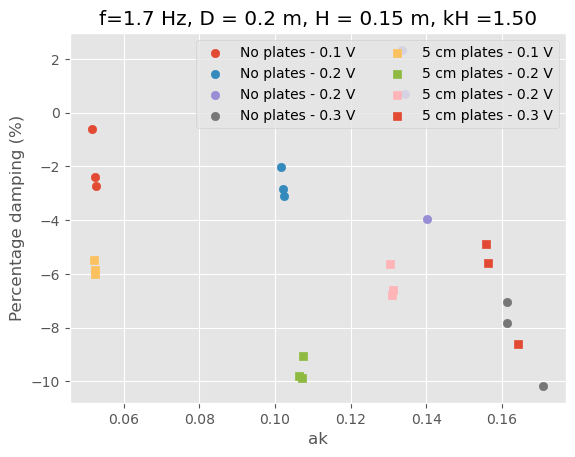

In [34]:
fig, ax = plt.subplots()

ax.scatter(ak_a01, perc_damp_a01, color='C0', label='No plates - 0.1 V', marker='o')
ax.scatter(ak_a02, perc_damp_a02, color='C1', label='No plates - 0.2 V',marker='o')
ax.scatter(ak_a025, perc_damp_a025, color='C2', label='No plates - 0.2 V',marker='o')
ax.scatter(ak_a03, perc_damp_a03, color='C3', label='No plates - 0.3 V',marker='o')

ax.scatter(ak_a01_p005, perc_damp_a01_p005, color='C4', label='5 cm plates - 0.1 V', marker='s')
ax.scatter(ak_a02_p005, perc_damp_a02_p005, color='C5', label='5 cm plates - 0.2 V', marker='s')
ax.scatter(ak_a025_p005, perc_damp_a025_p005, color='C6', label='5 cm plates - 0.2 V', marker='s')
ax.scatter(ak_a03_p005, perc_damp_a03_p005, color='C7', label='5 cm plates - 0.3 V', marker='s')

ax.set_xlabel('ak')
ax.set_ylabel('Percentage damping (%)')

ax.legend(ncol=2)
ax.set_title(f'f={freq} Hz, D = {depth} m, H = 0.15 m, kH ={k*depth:.2f}')

In [35]:
print('Wave steepness (no plates):')
for no, label in zip([a01, a02, a025, a03], ['A=0.1 V', 'A=0.2 V', 'A=0.25 V', 'A=0.3 V']):
    ak = no['Amp_obs_P0'] * k
    print(f'{label}: {ak.values[0]:.4f}')
print('Wave steepness (with 5 cm plates):')
for p005, label in zip([a01_p005, a02_p005, a025_p005, a03_p005], ['A=0.1 V', 'A=0.2 V', 'A=0.25 V', 'A=0.3 V']):
    ak = p005['Amp_obs_P0'] * k
    print(f'{label}: {ak.values[0]:.4f}')

Wave steepness (no plates):
A=0.1 V: 0.0517
A=0.2 V: 0.1015
A=0.25 V: 0.1400
A=0.3 V: 0.1614
Wave steepness (with 5 cm plates):
A=0.1 V: 0.0522
A=0.2 V: 0.1075
A=0.25 V: 0.1303
A=0.3 V: 0.1559


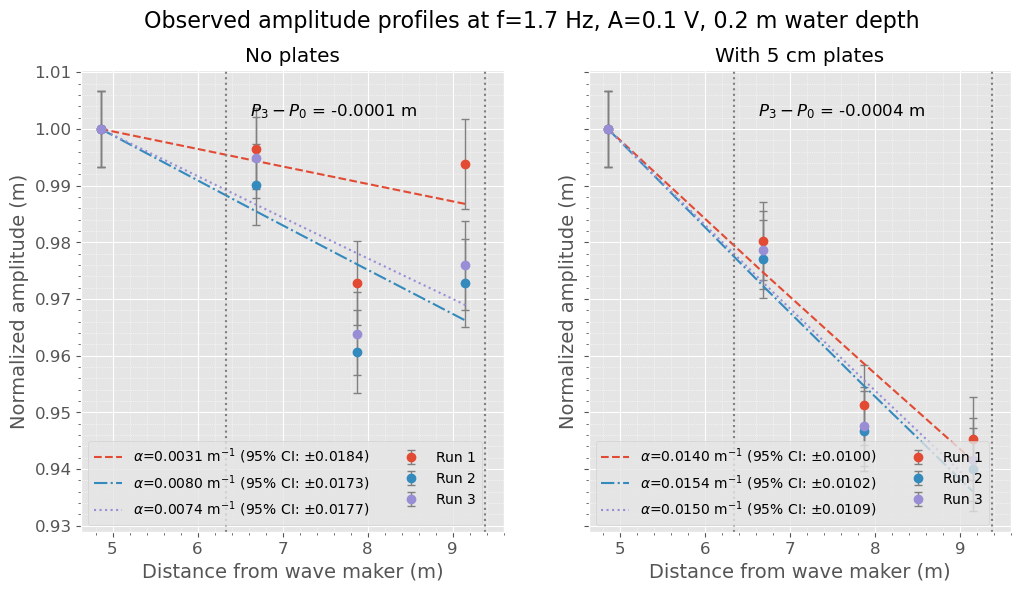

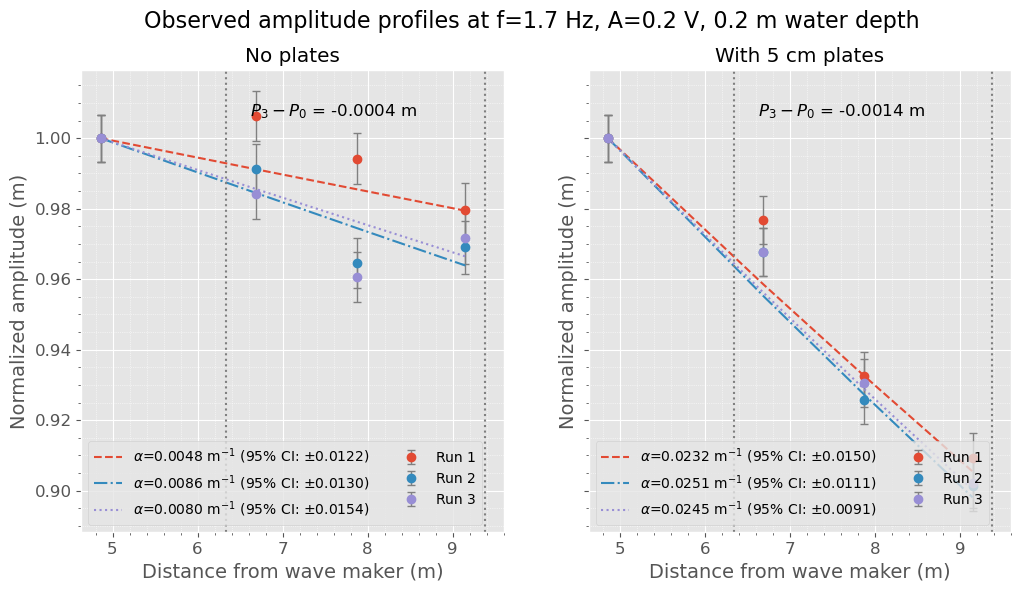

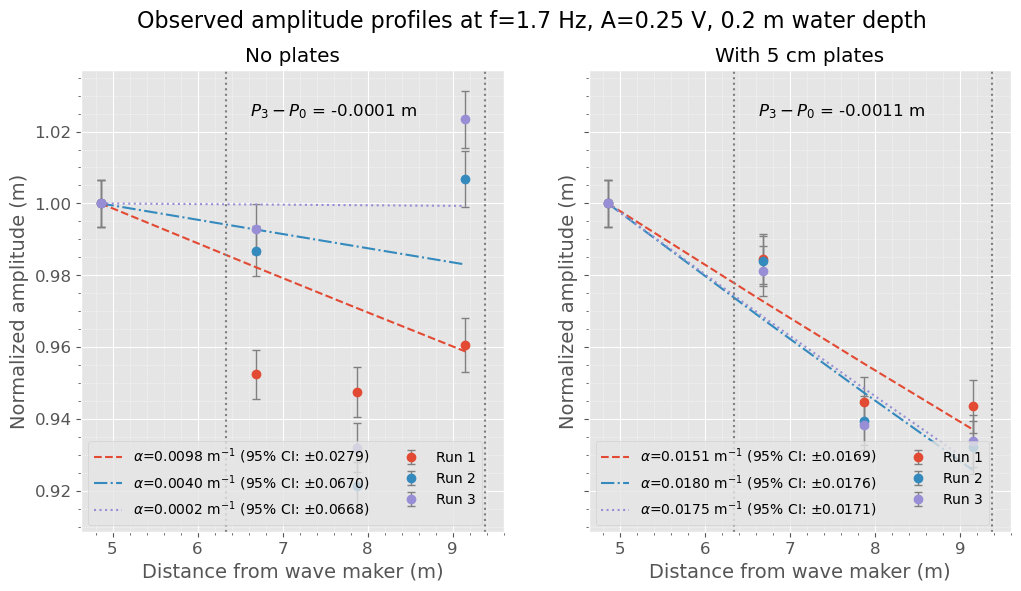

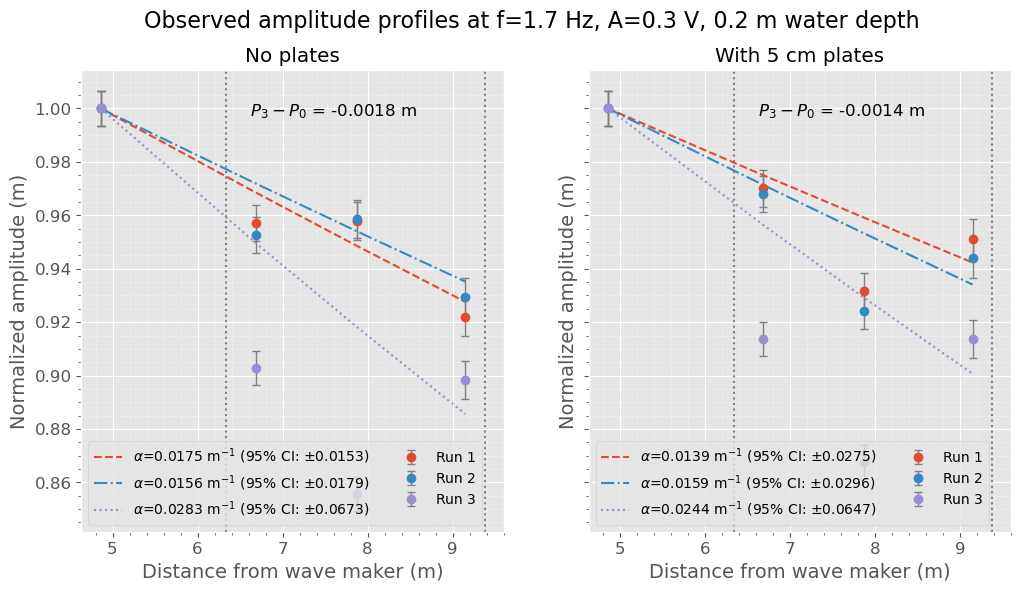

In [36]:
files = [(a01, a01_p005),
         (a02, a02_p005),
         (a025, a025_p005),
         (a03, a03_p005)]

volts = [0.1, 0.2, 0.25, 0.3]

x_prof = x_probe_pos - x_probe_pos[0]  # positions relative to first probe

for (no, p005), volt in zip(files, volts):
    # Extract amplitudes and normalize by first probe amplitude
    # No plates
    amp_r1 = [no.iloc[0]['Amp_obs_P0'], no.iloc[0]['Amp_obs_P1'], no.iloc[0]['Amp_obs_P2'], no.iloc[0]['Amp_obs_P3']]
    amp_r2 = [no.iloc[1]['Amp_obs_P0'], no.iloc[1]['Amp_obs_P1'], no.iloc[1]['Amp_obs_P2'], no.iloc[1]['Amp_obs_P3']]
    amp_r3 = [no.iloc[2]['Amp_obs_P0'], no.iloc[2]['Amp_obs_P1'], no.iloc[2]['Amp_obs_P2'], no.iloc[2]['Amp_obs_P3']]

    norm_amp_r1 = amp_r1 / amp_r1[0]
    norm_amp_r2 = amp_r2 / amp_r2[0]
    norm_amp_r3 = amp_r3 / amp_r3[0]
    
    # Extract amplitude errors
    err_r1 = [no.iloc[0]['Amp_errors_P0'], no.iloc[0]['Amp_errors_P1'], no.iloc[0]['Amp_errors_P2'], no.iloc[0]['Amp_errors_P3']]
    err_r2 = [no.iloc[1]['Amp_errors_P0'], no.iloc[1]['Amp_errors_P1'], no.iloc[1]['Amp_errors_P2'], no.iloc[1]['Amp_errors_P3']]
    err_r3 = [no.iloc[2]['Amp_errors_P0'], no.iloc[2]['Amp_errors_P1'], no.iloc[2]['Amp_errors_P2'], no.iloc[2]['Amp_errors_P3']]

    # Normalize errors by first probe amplitude
    err_r1 = err_r1 / amp_r1[0]
    err_r2 = err_r2 / amp_r2[0]
    err_r3 = err_r3 / amp_r3[0]

    # Same for 5 cm plates
    amp_p005_r1 = [p005.iloc[0]['Amp_obs_P0'], p005.iloc[0]['Amp_obs_P1'], p005.iloc[0]['Amp_obs_P2'], p005.iloc[0]['Amp_obs_P3']]
    amp_p005_r2 = [p005.iloc[1]['Amp_obs_P0'], p005.iloc[1]['Amp_obs_P1'], p005.iloc[1]['Amp_obs_P2'], p005.iloc[1]['Amp_obs_P3']]
    amp_p005_r3 = [p005.iloc[2]['Amp_obs_P0'], p005.iloc[2]['Amp_obs_P1'], p005.iloc[2]['Amp_obs_P2'], p005.iloc[2]['Amp_obs_P3']]

    norm_amp_p005_r1 = amp_p005_r1 / amp_p005_r1[0]
    norm_amp_p005_r2 = amp_p005_r2 / amp_p005_r2[0]
    norm_amp_p005_r3 = amp_p005_r3 / amp_p005_r3[0]

    err_p005_r1 = [p005.iloc[0]['Amp_errors_P0'], p005.iloc[0]['Amp_errors_P1'], p005.iloc[0]['Amp_errors_P2'], p005.iloc[0]['Amp_errors_P3']]
    err_p005_r2 = [p005.iloc[1]['Amp_errors_P0'], p005.iloc[1]['Amp_errors_P1'], p005.iloc[1]['Amp_errors_P2'], p005.iloc[1]['Amp_errors_P3']]
    err_p005_r3 = [p005.iloc[2]['Amp_errors_P0'], p005.iloc[2]['Amp_errors_P1'], p005.iloc[2]['Amp_errors_P2'], p005.iloc[2]['Amp_errors_P3']]

    err_p005_r1 = err_p005_r1 / amp_p005_r1[0]
    err_p005_r2 = err_p005_r2 / amp_p005_r2[0]
    err_p005_r3 = err_p005_r3 / amp_p005_r3[0]

    # Amplitude difference between first and last probe
    P3_minus_P0_no = np.mean([no.iloc[0]['P3_minus_P0'], no.iloc[1]['P3_minus_P0'], no.iloc[2]['P3_minus_P0']])
    P3_minus_P0_p005 = np.mean([p005.iloc[0]['P3_minus_P0'], p005.iloc[1]['P3_minus_P0'], p005.iloc[2]['P3_minus_P0']])

    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12,6))

    ax[0].errorbar(x_probe_pos,
                   norm_amp_r1,
                   yerr=err_r1,
                   fmt='o', color='C0', ecolor='0.5', elinewidth=1, capsize=3, label='Run 1')
    ax[0].errorbar(x_probe_pos,
                   norm_amp_r2,
                   yerr=err_r2,
                   fmt='o', color='C1', ecolor='0.5', elinewidth=1, capsize=3, label='Run 2')
    ax[0].errorbar(x_probe_pos,
                   norm_amp_r3,
                   yerr=err_r3,
                   fmt='o', color='C2', ecolor='0.5', elinewidth=1, capsize=3, label='Run 3')

    ax[1].errorbar(x_probe_pos,
                   norm_amp_p005_r1,
                   yerr=err_p005_r1,
                   fmt='o', color='C0', ecolor='0.5', elinewidth=1, capsize=3, label='Run 1')
    ax[1].errorbar(x_probe_pos,
                   norm_amp_p005_r2,
                   yerr=err_p005_r2,
                   fmt='o', color='C1', ecolor='0.5', elinewidth=1, capsize=3, label='Run 2')
    ax[1].errorbar(x_probe_pos,
                   norm_amp_p005_r3,
                   yerr=err_p005_r3,
                   fmt='o', color='C2', ecolor='0.5', elinewidth=1, capsize=3, label='Run 3')

    ax[0].annotate(r'$P_3 - P_0$' + f' = {P3_minus_P0_no:.4f} m', xy=(0.4, 0.9), xycoords='axes fraction', fontsize=12, color='black')
    ax[1].annotate(r'$P_3 - P_0$' + f' = {P3_minus_P0_p005:.4f} m', xy=(0.4, 0.9), xycoords='axes fraction', fontsize=12, color='black')

    #ax[0].annotate(rf'Theoretical $\alpha$={alpha_theo:.4f} m$^{{-1}}$', xy=(0.01, 0.2), xycoords='axes fraction', fontsize=10, color='black')
    #ax[1].annotate(rf'Theoretical $\alpha$={alpha_theo:.4f} m$^{{-1}}$', xy=(0.01, 0.2), xycoords='axes fraction', fontsize=10, color='black')


    # Plot fitted exponential decay curves and show alpha with CI bounds in legend
    ax[0].plot(
    x_probe_pos, np.exp(-no['Alpha_obs'][0]*x_prof),
    color='C0', linestyle='--',
    label=rf'$\alpha$={no["Alpha_obs"][0]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][0]*no["SE_Alpha_obs"][0]:.4f}$)'
)
    ax[0].plot(
    x_probe_pos, np.exp(-no['Alpha_obs'][1]*x_prof),
    color='C1', linestyle='-.',
    label=rf'$\alpha$={no["Alpha_obs"][1]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][1]*no["SE_Alpha_obs"][1]:.4f}$)'
)
    ax[0].plot(
    x_probe_pos, np.exp(-no['Alpha_obs'][2]*x_prof),
    color='C2', linestyle=':',
    label=rf'$\alpha$={no["Alpha_obs"][2]:.4f} m$^{{-1}}$ (95% CI: $\pm {no["T_val"][2]*no["SE_Alpha_obs"][2]:.4f}$)'
)

    ax[1].plot(
    x_probe_pos, np.exp(-p005['Alpha_obs'][0]*x_prof),
    color='C0', linestyle='--',
    label=rf'$\alpha$={p005["Alpha_obs"][0]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][0]*p005["SE_Alpha_obs"][0]:.4f}$)'
)
    ax[1].plot(
    x_probe_pos, np.exp(-p005['Alpha_obs'][1]*x_prof),
    color='C1', linestyle='-.',
    label=rf'$\alpha$={p005["Alpha_obs"][1]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][1]*p005["SE_Alpha_obs"][1]:.4f}$)'
)
    ax[1].plot(
    x_probe_pos, np.exp(-p005['Alpha_obs'][2]*x_prof),
    color='C2', linestyle=':',
    label=rf'$\alpha$={p005["Alpha_obs"][2]:.4f} m$^{{-1}}$ (95% CI: $\pm {p005["T_val"][2]*p005["SE_Alpha_obs"][2]:.4f}$)'
)

    for axs in ax:
        axs.set_xlabel('Distance from wave maker (m)', fontsize=14)
        axs.set_ylabel('Normalized amplitude (m)', fontsize=14)
        axs.tick_params(axis='both', which='major', labelsize=12)
        axs.legend(loc='lower left', ncol=2, fontsize=10)
        axs.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
        axs.minorticks_on()
        axs.axvline(x=plate_pos[0], color='0.5', linestyle=':')
        axs.axvline(x=plate_pos[1], color='0.5', linestyle=':')

    ax[0].set_title('No plates')
    ax[1].set_title('With 5 cm plates')

    fig.suptitle(f'Observed amplitude profiles at f={freq} Hz, A={volt} V, {depth} m water depth', fontsize=16)